<a href="https://colab.research.google.com/github/haramkim1003-uxu/-1/blob/main/250621_%EA%B8%B0_%EB%A7%90_%EA%B3%BC_%EC%A0%9C_%EA%B9%80_%ED%95%98_%EB%9E%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
myfiles = files.upload()

Saving df2.csv to df2 (3).csv


In [ ]:
import pandas as pd
import io

In [ ]:
df = pd.read_csv(io.BytesIO(myfiles['df2 (3).csv']))

In [ ]:
df

,연도,서울,부산,대구,인천,광주,대전,울산,세종
0,2015,6215,1774,1084,1542,860,698,532,46
1,2016,6683,1630,1028,1817,796,724,523,58
2,2017,7474,1936,999,1880,803,799,485,84
3,2018,6974,1712,1130,1743,792,848,496,106
4,2019,6977,1716,1095,1749,753,802,516,68
5,2020,6246,1593,917,1524,629,732,502,91
6,2021,5337,1481,925,1439,587,714,480,84
7,2022,6250,1693,1027,1599,631,810,500,121


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 36 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (11.5 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 126284 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


Saving df2.csv to df2.csv


/tmp/ipython-input-1-651502072.py:55: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1-651502072.py:55: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


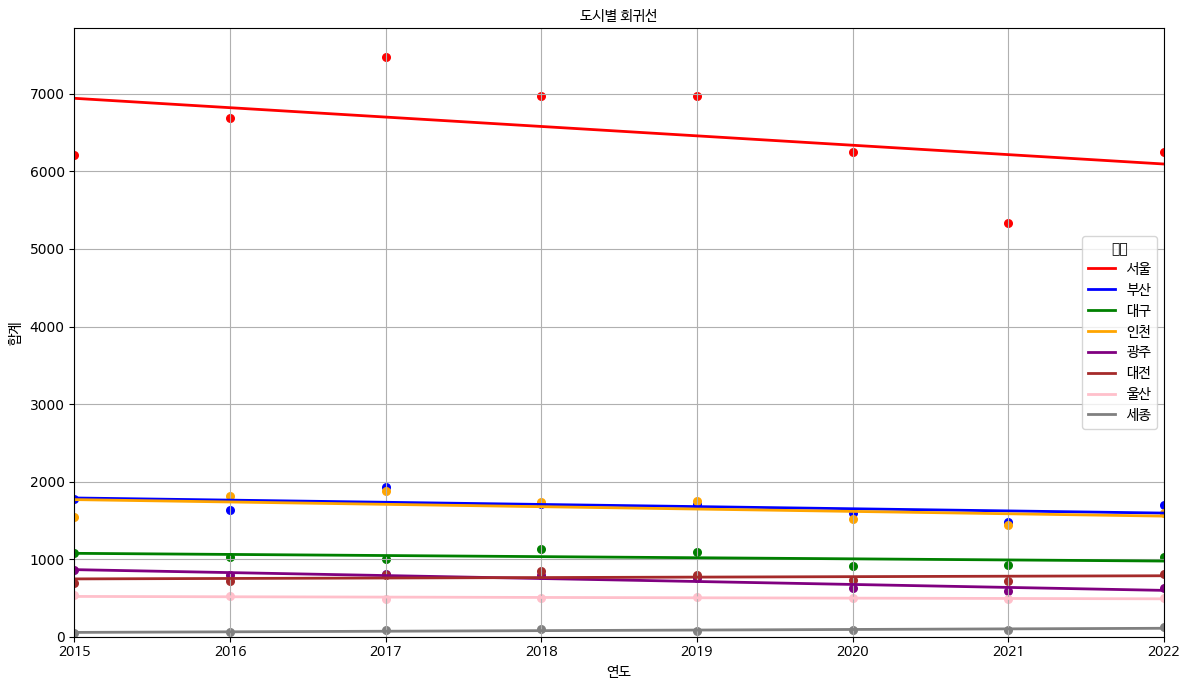

In [ ]:
from google.colab import files
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import matplotlib.font_manager as fm

# 1) 나눔글꼴 설치
!apt-get update -qq
!apt-get install -y fonts-nanum
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)

# 2) 파일 업로드
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# 3) 데이터 불러오기
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# 4) 상대 연도 생성
start_year = 2015
df['상대연도'] = df['연도'] - start_year
years = df['상대연도'].values.reshape(-1, 1)

# 5) 도시 및 색상 설정
cities = ['서울', '부산', '대구', '인천', '광주', '대전', '울산', '세종']
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']

# 6) 그래프 그리기
plt.figure(figsize=(12, 7))

for city, color in zip(cities, colors):
    y = df[city].values
    model = LinearRegression().fit(years, y)
    y_pred = model.predict(years)

    plt.scatter(df['연도'], y, s=30, color=color)
    plt.plot(df['연도'], y_pred, color=color, linewidth=2, label=city)

# 7) x축: 2015 ~ 2022 고정
plt.xlim(2015, 2022)
plt.xticks(ticks=np.arange(2015, 2023, 1), fontproperties=font_prop)

# 8) y축: 0부터 시작, 간격 자동 계산
plt.ylim(bottom=0)

# 9) 기타 설정
plt.xlabel('연도', fontproperties=font_prop)
plt.ylabel('합계', fontproperties=font_prop)
plt.title('도시별 회귀선', fontproperties=font_prop)
plt.legend(prop=font_prop, title='도시')
plt.grid(True)
plt.tight_layout()
plt.show()